In [1]:
cd Model/

/home/marcos/Escritorio/SERRATIA/Model


/home/marcos/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Top Down Reconstruction Metabolic Model - Serratia liquefaciens Strain UNJFSC 002

In [2]:
import escher # for visualization
from escher import Builder
import cobra # for model simulations
from time import sleep
escher.rc['never_ask_before_quit'] = True

In [3]:
!wget -nc http://bigg.ucsd.edu/static/models/iJO1366.json

model = cobra.io.load_json_model('iJO1366.json')

--2025-04-18 16:09:27--  http://bigg.ucsd.edu/static/models/iJO1366.json
Resolviendo bigg.ucsd.edu (bigg.ucsd.edu)... 169.228.33.117
Conectando con bigg.ucsd.edu (bigg.ucsd.edu)[169.228.33.117]:80... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 2948407 (2,8M) [application/json]
Guardando como: ‘iJO1366.json’

iJO1366.json        100%[===================>]   2,81M   703KB/s    en 4,6s    

2025-04-18 16:09:32 (621 KB/s) - ‘iJO1366.json’ guardado [2948407/2948407]



# Inspeccionar las Propiedades del Modelo Metabolico - GEMs

In [4]:
num_reactions = len(model.reactions)
num_metabolites = len(model.metabolites)
num_genes = len(model.genes)

print("Model information")
print("Model ID is: {}".format(model.id))
print("Number of reactions: {}".format(num_reactions))
print("Number of metabolites: {}".format(num_metabolites))
print("Number of genes: {}".format(num_genes))
print("Model compartments:")
for k, v in model.compartments.items():
    print(k + '\t' + v)
print("Model objective is:")
print(model.objective)

Model information
Model ID is: iJO1366
Number of reactions: 2583
Number of metabolites: 1805
Number of genes: 1367
Model compartments:
c	cytosol
e	extracellular space
p	periplasm
Model objective is:
Maximize
1.0*BIOMASS_Ec_iJO1366_core_53p95M - 1.0*BIOMASS_Ec_iJO1366_core_53p95M_reverse_5c8b1


In [5]:
## Funciones del Modelo
print(model.summary) #(float_format = None, names = True)) #mmol/gDW/h

<bound method Model.summary of <Model iJO1366 at 0x72c5002bdcf0>>


In [7]:
# Biomasa del Modelo - Metabolitos - Rx - Flux - Rangos - C-number - C-Flux
model.summary(fva=0.95) #, float_format = None, names = True)

Metabolite,Reaction,Flux,Range,C-Number,C-Flux
ca2_e,EX_ca2_e,0.005113,[0.004858; 0.005113],0,0.00%
cl_e,EX_cl_e,0.005113,[0.004858; 0.005113],0,0.00%
cobalt2_e,EX_cobalt2_e,2.456E-05,[2.333E-05; 2.456E-05],0,0.00%
cu2_e,EX_cu2_e,0.0006965,[0.0006617; 0.0006965],0,0.00%
fe2_e,EX_fe2_e,0.01578,[-4.978; 1000],0,0.00%
glc__D_e,EX_glc__D_e,10,[9.507; 10],6,100.00%
k_e,EX_k_e,0.1918,[0.1822; 0.1918],0,0.00%
mg2_e,EX_mg2_e,0.008522,[0.008096; 0.008522],0,0.00%
mn2_e,EX_mn2_e,0.0006788,[0.0006449; 0.0006788],0,0.00%
mobd_e,EX_mobd_e,0.0001267,[0.0001204; 0.0001271],0,0.00%


### Reacciones del Modelo Metabolico de iJO1366 para Serratia liquefaciens Strain UNJFSC 002 - (Nitrogeno - Fosfato - GABA - IAA)

In [8]:
def buscar_reacciones(modelo, palabra_clave):
    resultados = []
    for rxn in modelo.reactions:
        if palabra_clave.lower() in rxn.name.lower() or palabra_clave.lower() in rxn.id.lower():
            resultados.append((rxn.id, rxn.name))
    return resultados

In [9]:
# Para poder guardar los formatos en "csv" activamos pandas
import pandas as pd

In [11]:
reacciones_nitrogeno = []
for keyword in ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']:
    reacciones_nitrogeno += buscar_reacciones(model, keyword)
# Eliminar duplicados
reacciones_nitrogeno = list(set(reacciones_nitrogeno))
# Convertir a DataFrame
df_nitrogeno = pd.DataFrame(reacciones_nitrogeno, columns=["reaction_id", "reaction_name"])
# Exportar a CSV
df_nitrogeno.to_csv("reacciones_nitrogeno.csv", index=False)
# Opcional: imprimir para revisar
print(df_nitrogeno.head())

             reaction_id                                      reaction_name
0                NO3t7pp  Nitrate transport in via nitrite antiport (per...
1               GLNabcpp   L-glutamine transport via ABC system (periplasm)
2  EX_LalaDgluMdapDala_e  L-alanine-D-glutamate-meso-2,6-diaminoheptaned...
3                 GLUtex  L-glutamate transport via diffusion (extracell...
4                  GLU5K                                 Glutamate 5-kinase


In [13]:
reacciones_fosfato = []
for keyword in ['phosphate', 'phosphatase', 'phosphonate', 'phosphorus']:
    reacciones_fosfato += buscar_reacciones(model, keyword)
# Eliminar duplicados
reacciones_fosfato = list(set(reacciones_fosfato))
# Convertir a DataFrame
df_fosfato = pd.DataFrame(reacciones_fosfato, columns=["reaction_id", "reaction_name"])
# Guardar como CSV
df_fosfato.to_csv("reacciones_fosfato.csv", index=False)
# Mostrar ejemplo
print(df_fosfato.head())

  reaction_id                                      reaction_name
0       NTPP4    Nucleoside triphosphate pyrophosphorylase (ctp)
1   PAPA141pp   Phosphatidate phosphatase (periplasmic, n-C14:1)
2        NTP5                    Nucleoside-triphosphatase (CTP)
3   ACPPAT141  Acyl-(acyl carrier protein):phosphate acyltran...
4        F6PP                 D-fructose 6-phosphate phosphatase


In [14]:
reacciones_gaba = buscar_reacciones(model, 'GABA')
# Convertir a DataFrame
df_gaba = pd.DataFrame(reacciones_gaba, columns=["reaction_id", "reaction_name"])
# Exportar a CSV
df_gaba.to_csv("reacciones_gaba.csv", index=False)
# Mostrar primeras filas como verificación
print(df_gaba.head())

  reaction_id                                      reaction_name
0    GGGABADr  Gamma-glutamyl-gamma aminobutyric acid dehydro...
1     GGGABAH   Gamma-glutamyl-gamma-aminobutyric acid hydrolase


In [15]:
reacciones_iaa = []
for keyword in ['indole', 'tryptophan', 'IAA', 'indole-3-acetic']:
    reacciones_iaa += buscar_reacciones(model, keyword)
# Eliminar duplicados
reacciones_iaa = list(set(reacciones_iaa))
# Convertir a DataFrame
df_iaa = pd.DataFrame(reacciones_iaa, columns=["reaction_id", "reaction_name"])
# Guardar como CSV
df_iaa.to_csv("reacciones_iaa.csv", index=False)
# Verificar resultados
print(df_iaa.head())

   reaction_id                                      reaction_name
0     TRPt2rpp  L-tryptophan reversible transport via proton s...
1         IGPS               Indole-3-glycerol-phosphate synthase
2        TRPS1     Tryptophan synthase (indoleglycerol phosphate)
3  EX_indole_e                                    Indole exchange
4   INDOLEt2pp  Indole transport via proton symport, irreversi...


In [20]:
ls

iJO1366.json            reacciones_gaba.csv  reacciones_nitrogeno.csv
reacciones_fosfato.csv  reacciones_iaa.csv


## Creacion del Modelo Metabolico iJO1366

In [26]:
from escher import Builder
import json
import requests

In [35]:
escher.list_available_maps()

[{'organism': 'Saccharomyces cerevisiae',
  'map_name': 'iMM904.Central carbon metabolism'},
 {'organism': 'Homo sapiens',
  'map_name': 'RECON1.Inositol retinol metabolism'},
 {'organism': 'Homo sapiens', 'map_name': 'RECON1.Glycolysis TCA PPP'},
 {'organism': 'Homo sapiens', 'map_name': 'RECON1.Tryptophan metabolism'},
 {'organism': 'Homo sapiens', 'map_name': 'RECON1.Carbohydrate metabolism'},
 {'organism': 'Homo sapiens',
  'map_name': 'RECON1.Amino acid metabolism (partial)'},
 {'organism': 'Escherichia coli', 'map_name': 'iJO1366.Nucleotide metabolism'},
 {'organism': 'Escherichia coli',
  'map_name': 'iJO1366.Fatty acid biosynthesis (saturated)'},
 {'organism': 'Escherichia coli',
  'map_name': 'iJO1366.Nucleotide and histidine biosynthesis'},
 {'organism': 'Escherichia coli', 'map_name': 'e_coli_core.Core metabolism'},
 {'organism': 'Escherichia coli', 'map_name': 'iJO1366.Central metabolism'},
 {'organism': 'Escherichia coli',
  'map_name': 'iJO1366.Fatty acid beta-oxidation'}

In [36]:
escher.list_available_models()

[{'organism': 'Saccharomyces cerevisiae', 'model_name': 'iMM904'},
 {'organism': 'Homo sapiens', 'model_name': 'RECON1'},
 {'organism': 'Escherichia coli', 'model_name': 'e_coli_core'},
 {'organism': 'Escherichia coli', 'model_name': 'iJO1366'}]

In [37]:
builder = Builder(
    map_name='iJO1366.Central metabolism',
    model_name='iJO1366'
)

In [39]:
builder = Builder(
    height=600,
    map_name=None,
    model_name='iJO1366',
    map_json='https://escher.github.io/1-0-0/6/models/Escherichia%20coli/iJO1366.json',
)
builder

Builder(height=600, never_ask_before_quit=True)

In [40]:
builder = Builder(
    height=600,
    map_name=None,
    model_name='iJO1366',
    map_json='https://escher.github.io/1-0-0/6/maps/Escherichia%20coli/iJO1366.Central%20metabolism.json',
)
builder.save_html('mi_mapitaa.html')

In [64]:
timestep = 0.1
duration = 90 # seconds
min_flux = 0 # minimum flux value
max_flux = 50 # maximum flux value
step = 1 # increment in flux value
val = min_flux
with model:
    for _ in range(int(duration / timestep)):
        model.reactions.EX_o2_e.lower_bound = -val # exchange flux variation
        solution = model.optimize() # solve model
        builder.reaction_data = solution.fluxes # add fluxes to model
        if val <= max_flux:
            val += step # increment step
        else:
            val = min_flux # reset
        sleep(timestep)

In [65]:
builder.save_html('E_coli_Draft_Central_map.html')

In [66]:
escher.list_available_maps()

[{'organism': 'Saccharomyces cerevisiae',
  'map_name': 'iMM904.Central carbon metabolism'},
 {'organism': 'Homo sapiens',
  'map_name': 'RECON1.Inositol retinol metabolism'},
 {'organism': 'Homo sapiens', 'map_name': 'RECON1.Glycolysis TCA PPP'},
 {'organism': 'Homo sapiens', 'map_name': 'RECON1.Tryptophan metabolism'},
 {'organism': 'Homo sapiens', 'map_name': 'RECON1.Carbohydrate metabolism'},
 {'organism': 'Homo sapiens',
  'map_name': 'RECON1.Amino acid metabolism (partial)'},
 {'organism': 'Escherichia coli', 'map_name': 'iJO1366.Nucleotide metabolism'},
 {'organism': 'Escherichia coli',
  'map_name': 'iJO1366.Fatty acid biosynthesis (saturated)'},
 {'organism': 'Escherichia coli',
  'map_name': 'iJO1366.Nucleotide and histidine biosynthesis'},
 {'organism': 'Escherichia coli', 'map_name': 'e_coli_core.Core metabolism'},
 {'organism': 'Escherichia coli', 'map_name': 'iJO1366.Central metabolism'},
 {'organism': 'Escherichia coli',
  'map_name': 'iJO1366.Fatty acid beta-oxidation'}

## Ahora crearemos Modelos especificos para Ciclos de (N y P)

In [44]:
def buscar_reacciones(modelo, palabra):
    return [rxn.id for rxn in modelo.reactions if palabra.lower() in rxn.name.lower() or palabra.lower() in rxn.id.lower()]

# Palabras clave para buscar rutas
keywords_n = ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']
keywords_p = ['phosphate', 'phosphatase', 'phosphonate', 'phosphorus']

# Buscar reacciones
reacciones_nitrogeno = []
reacciones_fosfato = []

for palabra in keywords_n:
    reacciones_nitrogeno += buscar_reacciones(model, palabra)

for palabra in keywords_p:
    reacciones_fosfato += buscar_reacciones(model, palabra)

# Eliminar duplicados
reacciones_nitrogeno = list(set(reacciones_nitrogeno))
reacciones_fosfato = list(set(reacciones_fosfato))

In [46]:
builder = Builder(
    model=model,
    reaction_ids=reacciones_nitrogeno + reacciones_fosfato,
    height=600
)
# Guardar como HTML
builder.save_html("ruta_nitrogeno_fosfato.html")

/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


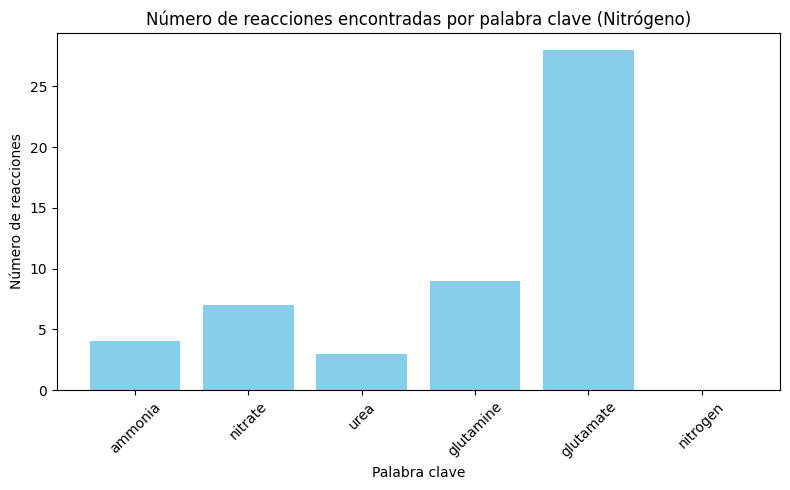

In [47]:
## Reaccion de Nitrogeno
import matplotlib.pyplot as plt

conteo_keywords = {}
for keyword in ['ammonia', 'nitrate', 'urea', 'glutamine', 'glutamate', 'nitrogen']:
    matches = buscar_reacciones(model, keyword)
    conteo_keywords[keyword] = len(matches)

# Graficar
plt.figure(figsize=(8, 5))
plt.bar(conteo_keywords.keys(), conteo_keywords.values(), color='skyblue')
plt.title("Número de reacciones encontradas por palabra clave (Nitrógeno)")
plt.ylabel("Número de reacciones")
plt.xlabel("Palabra clave")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
# Ecuaciones Quimicas de las Reacciones de Nitrogeno
for rxn_id in df_nitrogeno["reaction_id"]:
    rxn = model.reactions.get_by_id(rxn_id)
    print(f"{rxn.id}: {rxn.reaction}")

NO3t7pp: no2_c + no3_p --> no2_p + no3_c
GLNabcpp: atp_c + gln__L_p + h2o_c --> adp_c + gln__L_c + h_c + pi_c
EX_LalaDgluMdapDala_e: LalaDgluMdapDala_e --> 
GLUtex: glu__L_e <=> glu__L_p
GLU5K: atp_c + glu__L_c --> adp_c + glu5p_c
UREAtpp: urea_p <=> urea_c
CBPS: 2.0 atp_c + gln__L_c + h2o_c + hco3_c --> 2.0 adp_c + cbp_c + glu__L_c + 2.0 h_c + pi_c
SGDS: h2o_c + sucglu_c --> glu__L_c + succ_c
LALADGLUtex: LalaDglu_e <=> LalaDglu_p
ACGS: accoa_c + glu__L_c --> acglu_c + coa_c + h_c
LALALGLUtpp: LalaLglu_p + h_p --> LalaLglu_c + h_c
GLUSy: akg_c + gln__L_c + h_c + nadph_c --> 2.0 glu__L_c + nadp_c
EX_nh4_e: nh4_e <=> 
EX_no3_e: no3_e --> 
NO3R2bpp: mql8_c + no3_p --> h2o_p + mqn8_c + no2_p
GLUPRT: gln__L_c + h2o_c + prpp_c --> glu__L_c + ppi_c + pram_c
GLUR: glu__D_c <=> glu__L_c
ETHAAL: etha_c --> acald_c + nh4_c
NH4tpp: nh4_p <=> nh4_c
GLUDC: glu__L_c + h_c --> 4abut_c + co2_c
EX_LalaDgluMdap_e: LalaDgluMdap_e --> 
GLNtex: gln__L_e <=> gln__L_p
G5SADs: glu5sa_c --> 1pyr5c_c + h2o_c + 

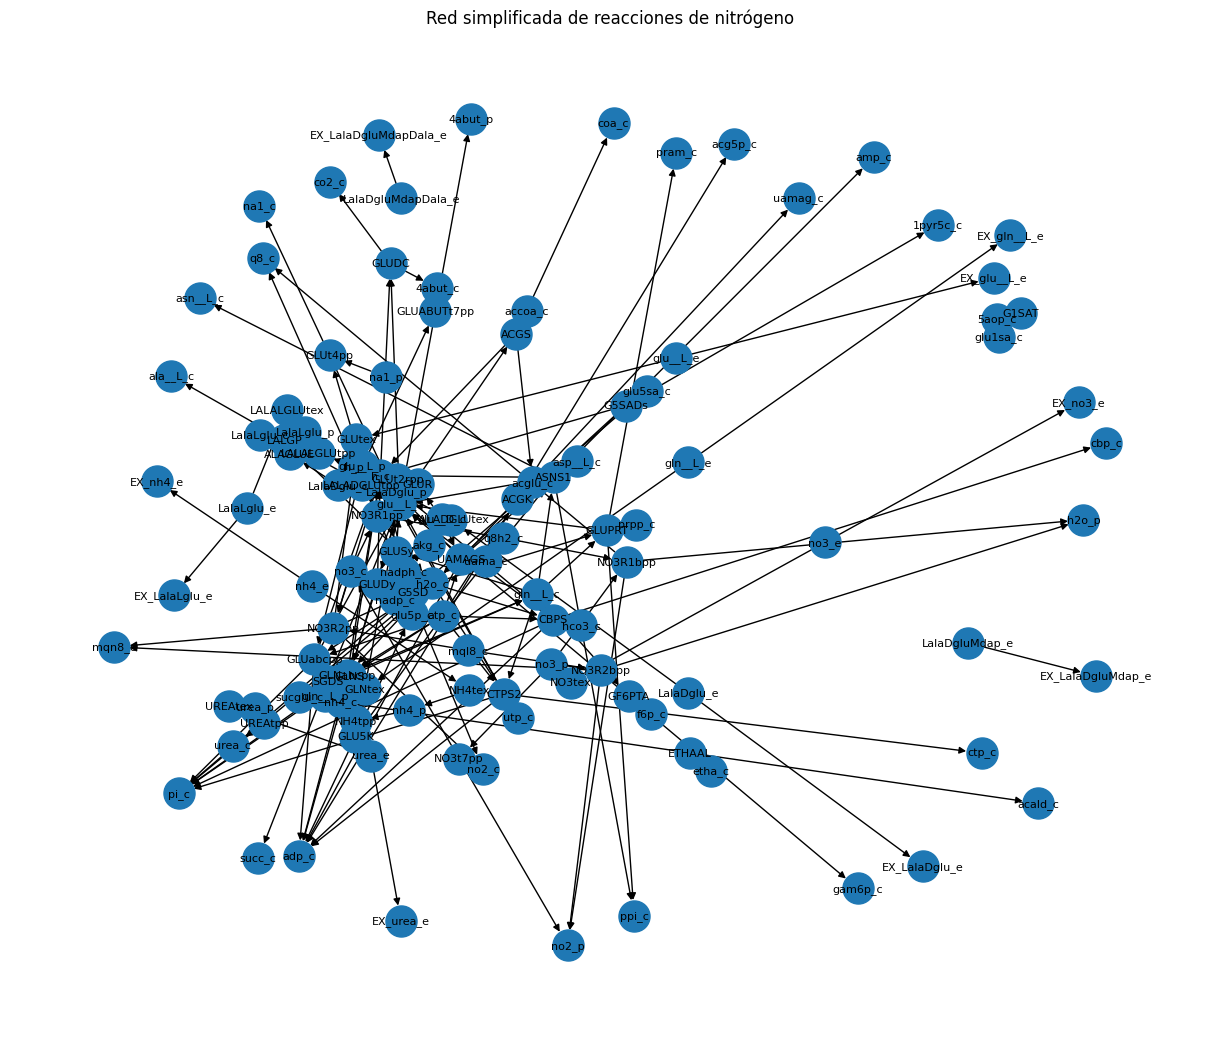

In [51]:
#Red de Nitrogeno usando networkx
import networkx as nx

G = nx.DiGraph()
for rxn_id in df_nitrogeno["reaction_id"]:
    rxn = model.reactions.get_by_id(rxn_id)
    for met in rxn.reactants:
        G.add_edge(met.id, rxn.id)
    for met in rxn.products:
        G.add_edge(rxn.id, met.id)

plt.figure(figsize=(12, 10))
nx.draw(G, with_labels=True, node_size=500, font_size=8)
plt.title("Red simplificada de reacciones de nitrógeno")
plt.show()

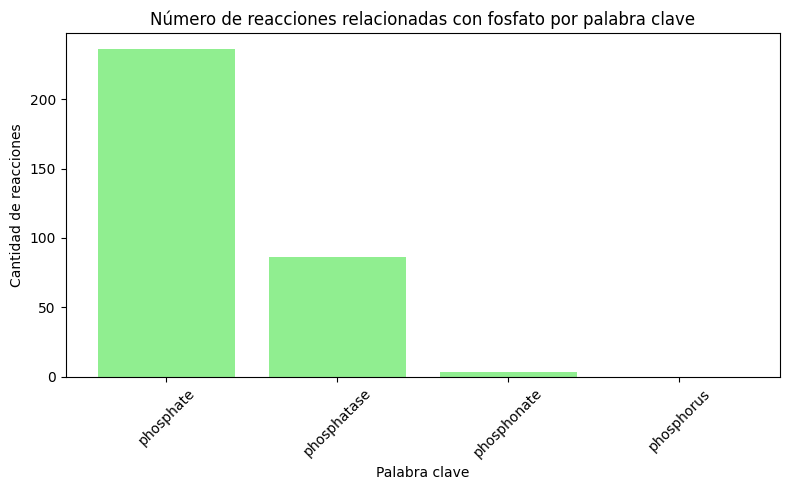

In [52]:
keywords_fosfato = ['phosphate', 'phosphatase', 'phosphonate', 'phosphorus']
conteo_keywords_fosfato = {kw: len(buscar_reacciones(model, kw)) for kw in keywords_fosfato}

plt.figure(figsize=(8, 5))
plt.bar(conteo_keywords_fosfato.keys(), conteo_keywords_fosfato.values(), color='lightgreen')
plt.title("Número de reacciones relacionadas con fosfato por palabra clave")
plt.ylabel("Cantidad de reacciones")
plt.xlabel("Palabra clave")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [54]:
#Ecuaciones de las Rx de Fosfato
for rxn_id in df_fosfato["reaction_id"]:
    rxn = model.reactions.get_by_id(rxn_id)
    print(f"{rxn.id}: {rxn.reaction}")

NTPP4: ctp_c + h2o_c --> cmp_c + h_c + ppi_c
PAPA141pp: h2o_p + pa141_p --> 12dgr141_p + pi_p
NTP5: ctp_c + h2o_c --> cdp_c + h_c + pi_c
ACPPAT141: h_c + pi_c + tdeACP_c --> ACP_c + ttdceap_c
F6PP: f6p_c + h2o_c --> fru_c + pi_c
EX_glyc3p_e: glyc3p_e --> 
GDPMNP: gdpmann_c + h2o_c --> gmp_c + 2.0 h_c + man1p_c
PPTHpp: h2o_p + ppt_p --> h2_p + pi_p
RNDR1: adp_c + trdrd_c --> dadp_c + h2o_c + trdox_c
UPLA4FNT: udcpp_c + udpLa4fn_c --> uLa4fn_c + udp_c
GUR1PPpp: glcur1p_p + h2o_p --> glcur_p + pi_p
PTA2: pi_c + ppcoa_c --> coa_c + ppap_c
PGP120abcpp: atp_c + h2o_c + pgp120_c --> adp_c + h_c + pgp120_p + pi_c
UDCPPtppi: udcpp_p --> udcpp_c
G3PD7: 2dmmq8_c + glyc3p_c --> 2dmmql8_c + dhap_c
DRPA: 2dr5p_c --> acald_c + g3p_c
IGPS: 2cpr5p_c + h_c --> 3ig3p_c + co2_c + h2o_c
RPE: ru5p__D_c <=> xu5p__D_c
EX_xmp_e: xmp_e --> 
PRPPS: atp_c + r5p_c <=> amp_c + h_c + prpp_c
PTPATi: atp_c + h_c + pan4p_c --> dpcoa_c + ppi_c
UDCPDP: h2o_c + udcpdp_c --> h_c + pi_c + udcpp_c
G6PP: g6p_c + h2o_c --> glc

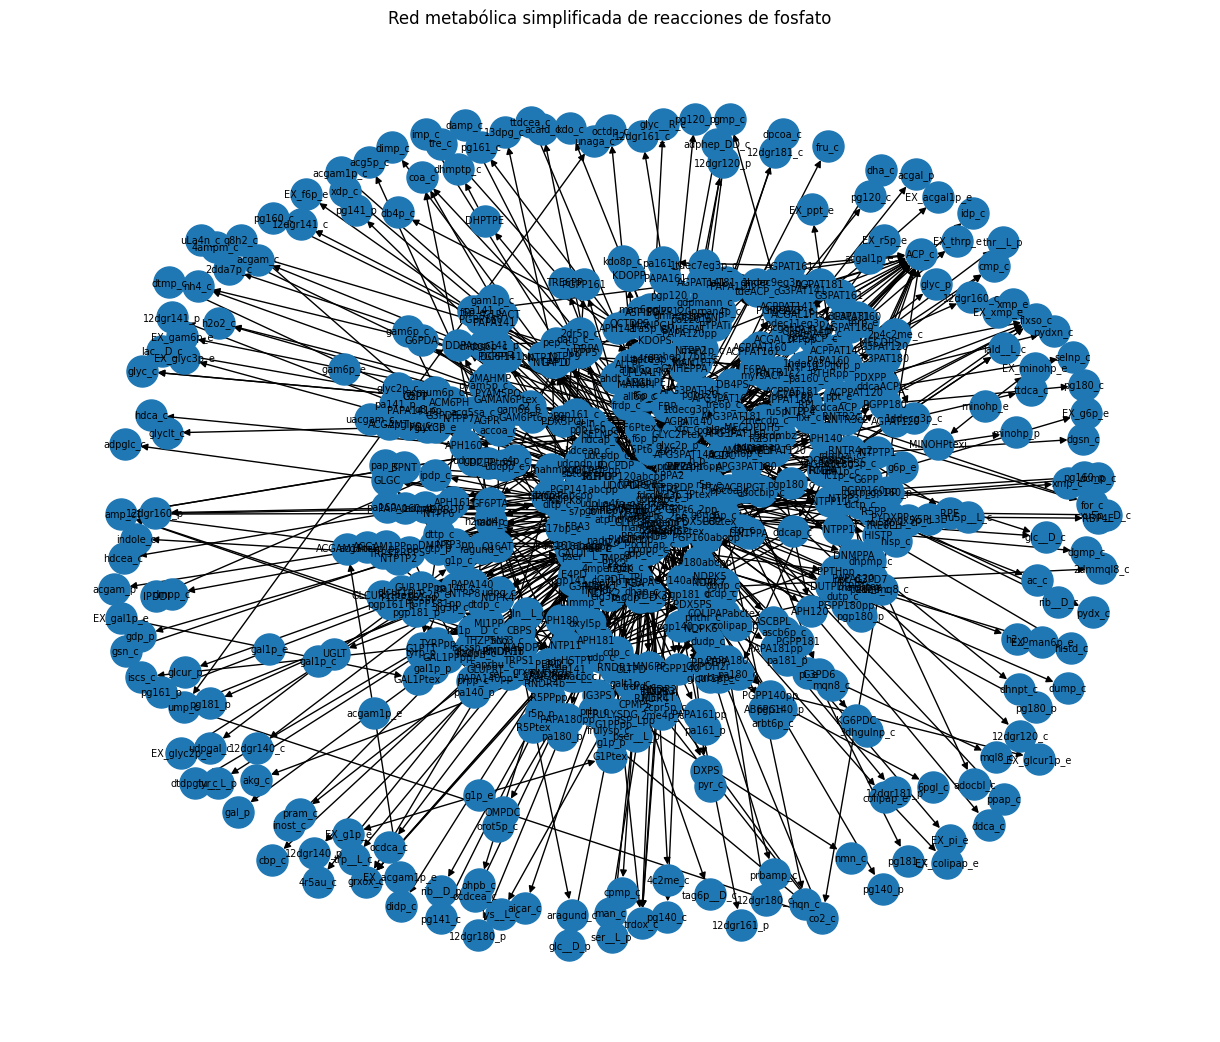

In [55]:
# Visualización de la Red de Fosfato
G = nx.DiGraph()
for rxn_id in df_fosfato["reaction_id"]:
    rxn = model.reactions.get_by_id(rxn_id)
    for met in rxn.reactants:
        G.add_edge(met.id, rxn.id)
    for met in rxn.products:
        G.add_edge(rxn.id, met.id)

plt.figure(figsize=(12, 10))
nx.draw(G, with_labels=True, node_size=500, font_size=7)
plt.title("Red metabólica simplificada de reacciones de fosfato")
plt.show()

/tmp/ipykernel_19059/3023881873.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


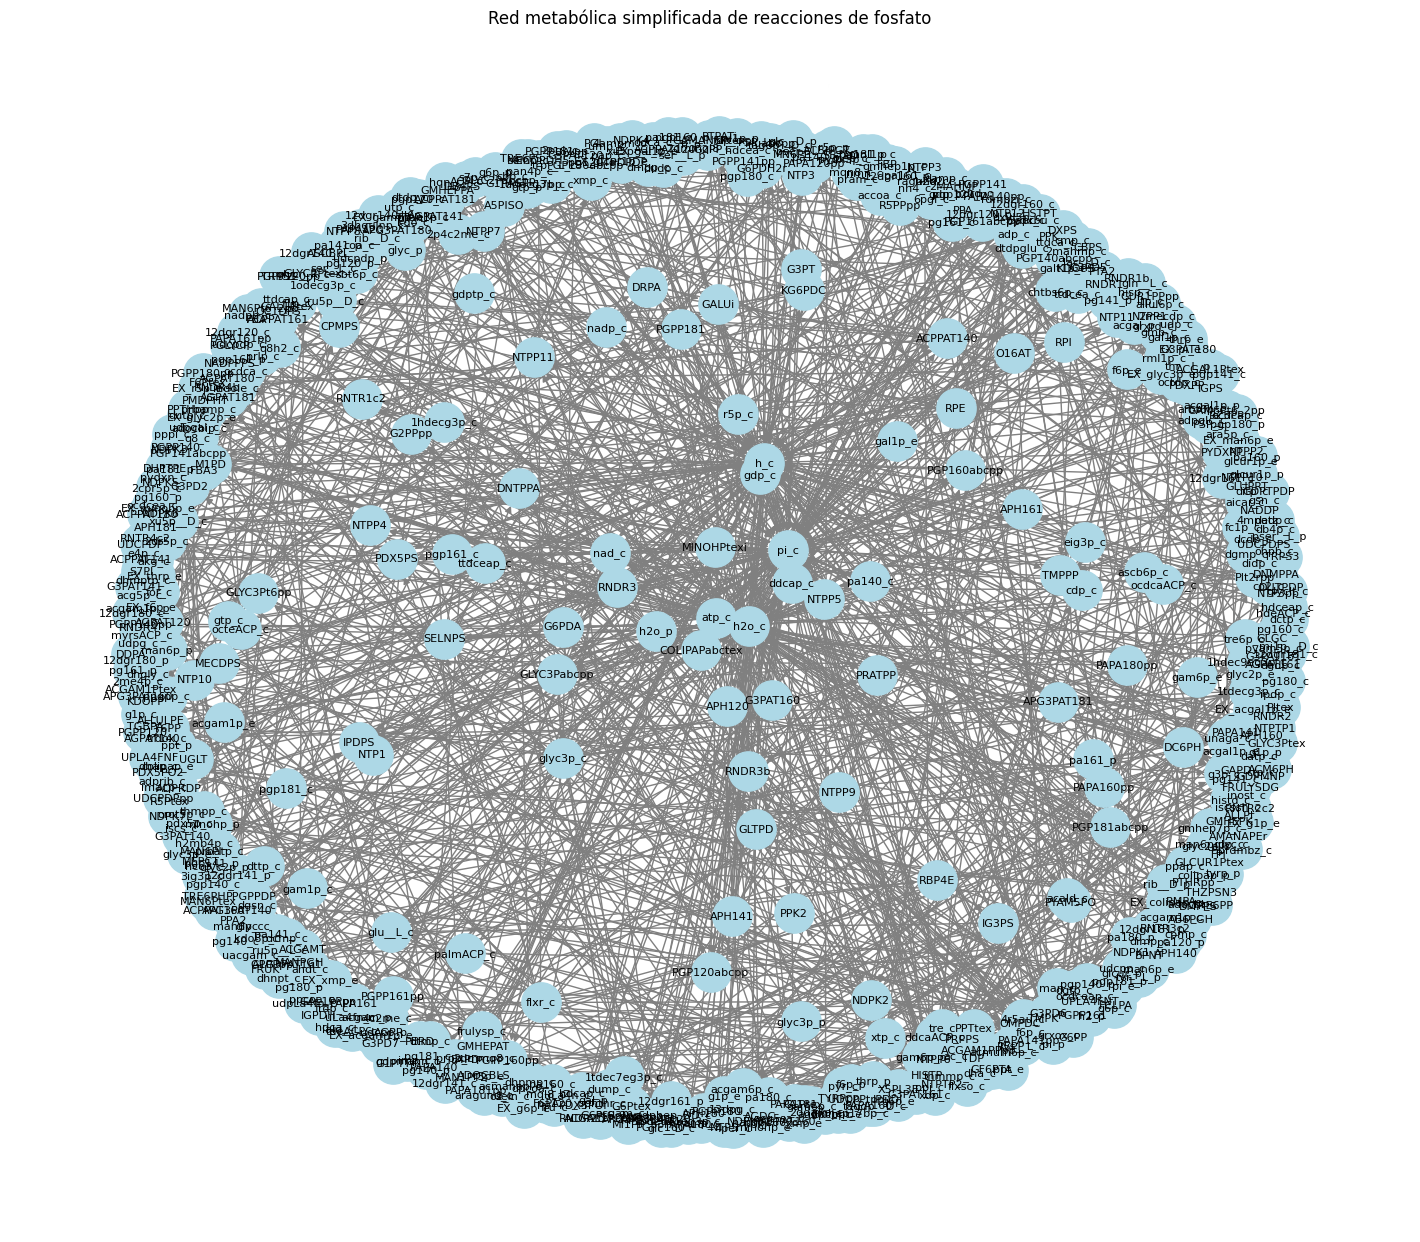

In [57]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear red dirigida
G = nx.DiGraph()
for rxn_id in df_fosfato["reaction_id"]:
    rxn = model.reactions.get_by_id(rxn_id)
    for met in rxn.reactants:
        G.add_edge(met.id, rxn.id)
    for met in rxn.products:
        G.add_edge(rxn.id, met.id)

# Generar layout con mayor separación
pos = nx.spring_layout(G, k=1.5, iterations=100)  # Aumentar k para más separación

# Dibujar la red
plt.figure(figsize=(14, 12))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=800,
    node_color="lightblue",
    edge_color="gray",
    font_size=8
)
plt.title("Red metabólica simplificada de reacciones de fosfato")
plt.tight_layout()
plt.show()

In [58]:
print(df_gaba.head())

  reaction_id                                      reaction_name
0    GGGABADr  Gamma-glutamyl-gamma aminobutyric acid dehydro...
1     GGGABAH   Gamma-glutamyl-gamma-aminobutyric acid hydrolase


/tmp/ipykernel_19059/3148437084.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


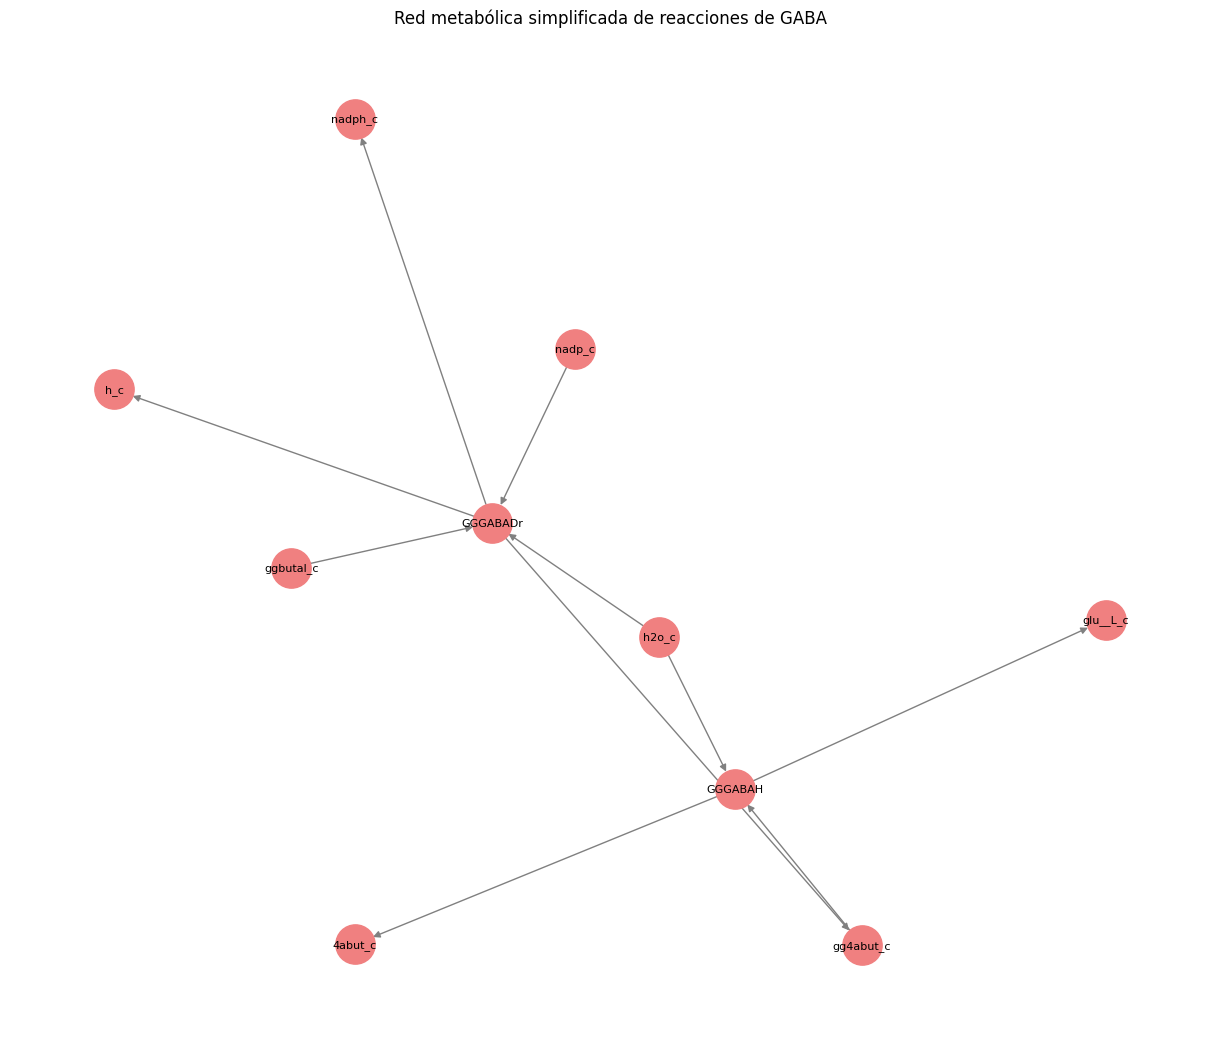

In [59]:
G = nx.DiGraph()
for rxn_id in df_gaba["reaction_id"]:
    rxn = model.reactions.get_by_id(rxn_id)
    for met in rxn.reactants:
        G.add_edge(met.id, rxn.id)
    for met in rxn.products:
        G.add_edge(rxn.id, met.id)

pos = nx.spring_layout(G, k=1.5, iterations=100)

plt.figure(figsize=(12, 10))
nx.draw(G, pos,
        with_labels=True,
        node_size=800,
        node_color="lightcoral",
        edge_color="gray",
        font_size=8)
plt.title("Red metabólica simplificada de reacciones de GABA")
plt.tight_layout()
plt.show()

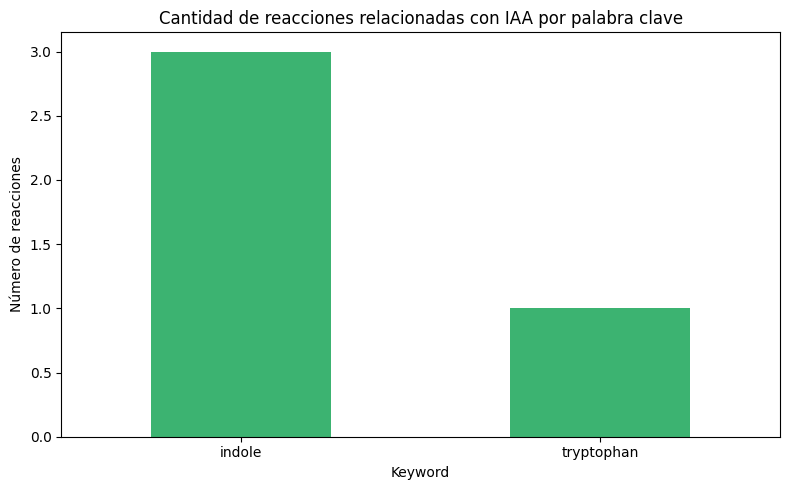

In [67]:
import matplotlib.pyplot as plt
import pandas as pd

# Asociar cada reacción con la palabra clave que la identificó
df_iaa_keywords = []
for keyword in ['indole', 'tryptophan', 'IAA', 'indole-3-acetic']:
    for rxn in buscar_reacciones(model, keyword):
        df_iaa_keywords.append((rxn[0], rxn[1], keyword))

# Convertir a DataFrame
df_iaa_full = pd.DataFrame(df_iaa_keywords, columns=["reaction_id", "reaction_name", "keyword"])
df_iaa_full.drop_duplicates(subset=["reaction_id"], inplace=True)

# Plot
plt.figure(figsize=(8, 5))
df_iaa_full['keyword'].value_counts().plot(kind='bar', color='mediumseagreen')
plt.title("Cantidad de reacciones relacionadas con IAA por palabra clave")
plt.xlabel("Keyword")
plt.ylabel("Número de reacciones")
plt.xticks(rotation=0)
plt.tight_layout()

/tmp/ipykernel_19059/3151292267.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


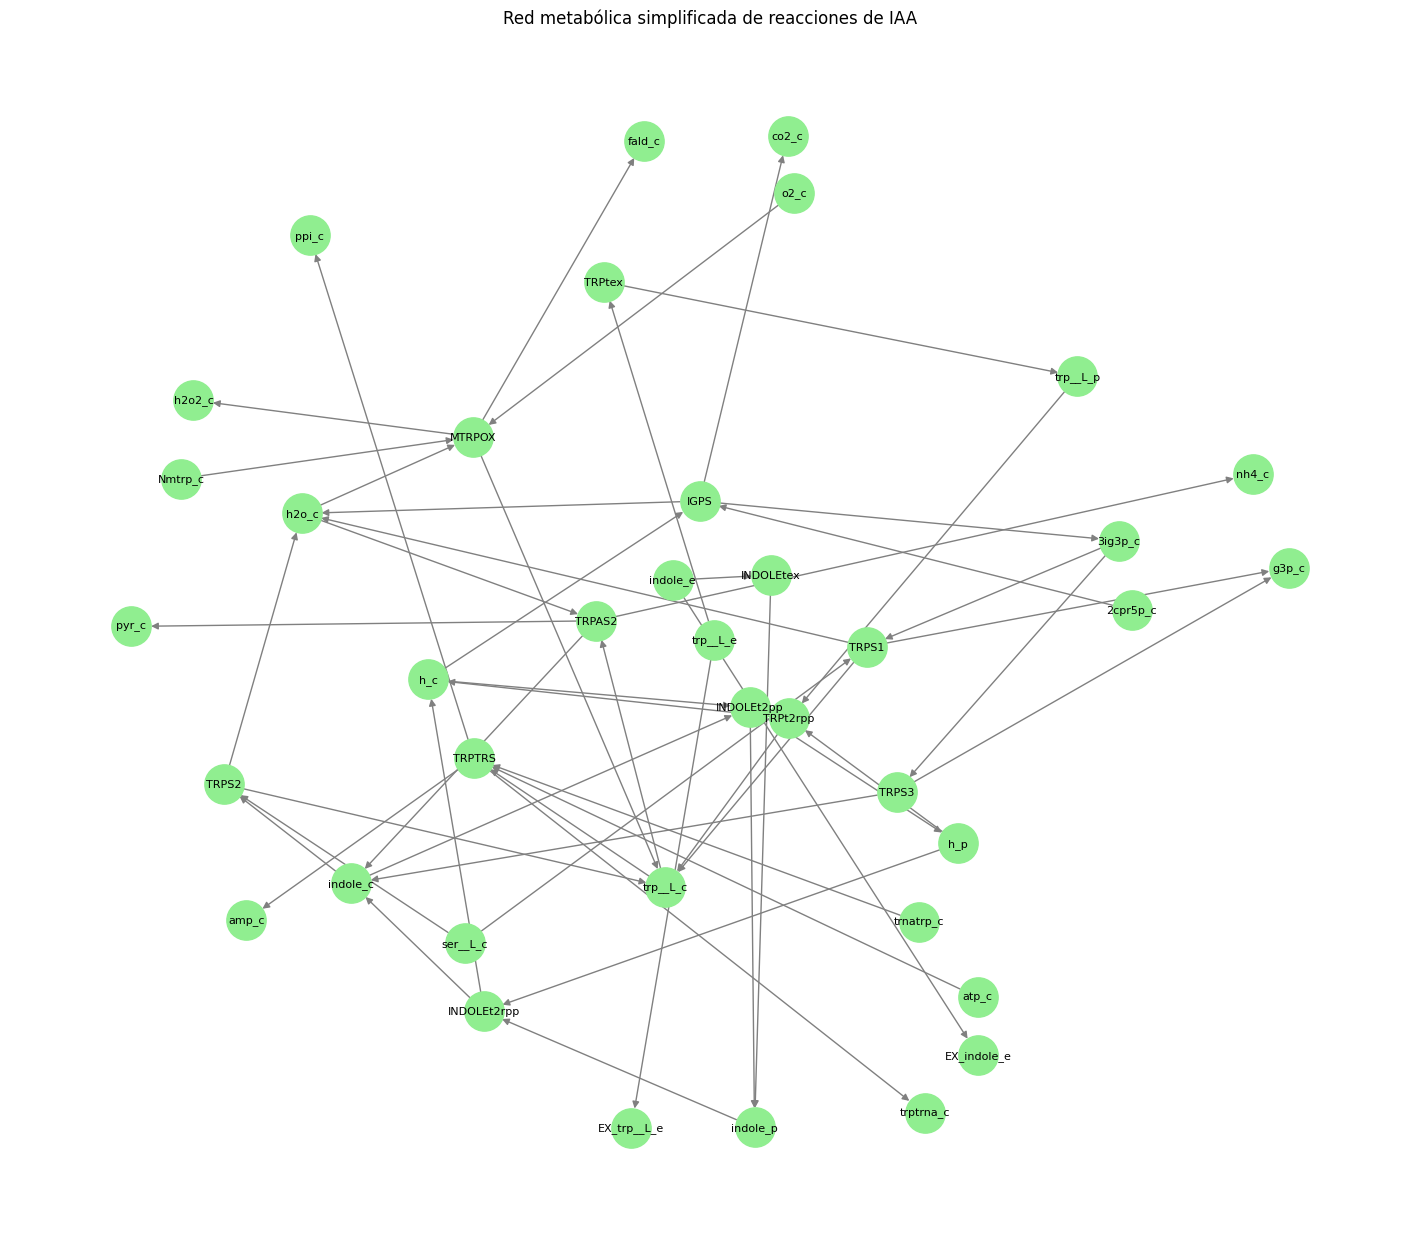

In [68]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear red dirigida
G = nx.DiGraph()
for rxn_id in df_iaa["reaction_id"]:
    try:
        rxn = model.reactions.get_by_id(rxn_id)
        for met in rxn.reactants:
            G.add_edge(met.id, rxn.id)
        for met in rxn.products:
            G.add_edge(rxn.id, met.id)
    except KeyError:
        print(f"Reacción no encontrada en el modelo: {rxn_id}")

# Layout con más separación
pos = nx.spring_layout(G, k=1.5, iterations=100)

# Dibujar
plt.figure(figsize=(14, 12))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=800,
    node_color="lightgreen",
    edge_color="gray",
    font_size=8
)
plt.title("Red metabólica simplificada de reacciones de IAA")
plt.tight_layout()
plt.show()

In [71]:
from escher import Builder
from cobra.io import load_json_model

# Cargar modelo
model = load_json_model("iJO1366.json")  # Asegúrate de tener el archivo

# Crear visualizador Escher con tu modelo y un mapa base (o sin mapa si lo quieres construir)
builder = Builder(model=model)

# Marcar las reacciones con datos (score = 1)
reacciones_iaa_ids = df_iaa["reaction_id"].tolist()
builder.reaction_data = {rxn_id: 1 for rxn_id in reacciones_iaa_ids}

# Mostrar en notebook
builder.display_in_notebook()

Exception: display_in_notebook is deprecated. The Builder is now a Jupyter Widget, so you can return the Builder in a cell to see it, or use the IPython display function (see Escher docs for details)